<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>Statistics</p>
    <o style='font-size:20px;'>This notebook handles calculating stats for all variations and putting them into a table</p>
</div>

In [2]:
import cogsworth
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [3]:
reload(constants)
files = constants.SIMULATION_FILES

main_labels = [
    r"$f_{\rm bin} = 1.0$",
    r"$f_{\rm bin} = 0.0$",
    "No BH kicks", "No fallback rescaling", "Hobbs2005",
    "Fryer2012 Rapid", r"Mandel\&Muller2020", "Maltsev2025 (Default)",
    r"$f_{\rm fb} = 0.0$", r"$f_{\rm fb} = 0.25$", r"$f_{\rm fb} = 0.75$", r"$f_{\rm fb} = 1.0$",
    r"$P({\rm pf}) = 0.0$", r"$P({\rm pf}) = 1.0$",
    'Time-evolving potential'
]
mt_labels = [
    r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$",
    r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$",
    r"$q_{\rm crit, B} = 0$", r"$q_{\rm crit, B} = \infty$",
]
labels = main_labels + mt_labels
mt_labels = [main_labels[0]] + mt_labels  # include the fiducial model in the MT section

paper_replacers = {
    "H25": r"\citet{Hobbs+2005}",
    "F12": r"\citet{Fryer+2012:2012ApJ...749...91F}",
    "MM20": r"\citet{Mandel+2020:2020MNRAS.499.3214M}",
    "M25": r"\citet{Maltsev+2025:2025AA...700A..20M}",
}

In [4]:
plot_labels = [
    "Fiducial",
    "Singles",
    "No BH kicks",
    "No fallback rescaling",
    "Hobbs2005",
    "Fryer2012 Rapid", r"Mandel&Muller2020", "Maltsev2025 (Default)",
    r"Maltsev2025 ($f_{\rm fb} = 0.0$)", r"Maltsev2025 ($f_{\rm fb} = 0.25$)", r"Maltsev2025 ($f_{\rm fb} = 0.75$)", r"Maltsev2025 ($f_{\rm fb} = 1.0$)",
    r"Maltsev2025 ($P({\rm pf}) = 0.0$)", r"Maltsev2025 ($P({\rm pf}) = 1.0$)",
    'Time-evolving potential',
    r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$",
    r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$",
    r"$q_{\rm crit, B} = 0$", r"$q_{\rm crit, B} = \infty$"
]

In [5]:
reload(helpers)
pops, data = helpers.load_postprocessed_pops(files, labels, [None] * len(files))

In [6]:
reload(plotting)

scale_heights = []
scale_height_errs = []

for label in labels:
    sh, sh_err, _, _ = plotting.estimate_scale_height(
        z=np.abs(data[label]["pos"]["BH"][:, 2],),
        bins=np.linspace(0, 3, 201),
        plot=False,
        xlim=(0, 3),
        n_components=2
    )
    scale_heights.append(sh * 1000)
    scale_height_errs.append(sh_err * 1000)

In [7]:
stats = {
    "scale_up": [6e10 / data[label]["mass_binaries"] for label in labels],
    "n_BH": [data[label]["n_BH"] for label in labels],
    "m_BH": [sum(data[label]["mass"]["BH"]) for label in labels],
    "scale_height": scale_heights,
    "scale_height_err": scale_height_errs,
    r"$f_{\rm esc}$": [data[label]["escaped"]["BH"].sum() / len(data[label]["escaped"]["BH"])
                       for label in labels],
    r"$\langle m \rangle_{|z| < 1 \, {\rm kpc}}$": [data[label]["mass"]["BH"][(abs(data[label]["pos"]["BH"][:, 2]) < 1) & ~(data[label]["escaped"]["BH"])].mean() for label in labels],
    r"$\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$": [data[label]["mass"]["BH"][(abs(data[label]["pos"]["BH"][:, 2]) >= 1) & ~(data[label]["escaped"]["BH"])].mean() for label in labels],
    r"$f_{\rm bound}$": [(data[label]["sep"]["BH"] > 0).sum() / data[label]["n_BH"] for label in labels],
    r"$f_{\rm merger}$": [(data[label]["sep"]["BH"] == 0).sum() / data[label]["n_BH"] for label in labels],
    r"$f_{\rm unbound}$": [(data[label]["sep"]["BH"] < 0).sum() / data[label]["n_BH"] for label in labels],
}

df = pd.DataFrame(stats)
df.index = labels

# fix stats for singles because wide binaries make it funky
df.loc[r"$f_{\rm bin} = 0.0$", [r"$f_{\rm bound}$", r"$f_{\rm merger}$", r"$f_{\rm unbound}$"]] = [0.0, 0.0, 1.0]

df["n_BH"] *= df["scale_up"]
df["m_BH"] *= df["scale_up"]
del df["scale_up"]

df["n_BH"] /= 1e8
df["m_BH"] /= 1e9

latex_header = [r"$N_{\rm BH} / 10^8$", r"$M_{\rm BH} / 10^9 M_\odot$", r"$h_z$ (pc)", r"$\sigma_{h_z}$ (pc)"]
df.rename(columns=dict(zip(df.columns, latex_header)), inplace=True)

df.round(2)

,$N_{\rm BH} / 10^8$,$M_{\rm BH} / 10^9 M_\odot$,$h_z$ (pc),$\sigma_{h_z}$ (pc),$f_{\rm esc}$,"$\langle m \rangle_{|z| < 1 \, {\rm kpc}}$","$\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$",$f_{\rm bound}$,$f_{\rm merger}$,$f_{\rm unbound}$
$f_{\rm bin} = 1.0$,1.87,1.71,549.55,16.53,0.03,10.02,7.68,0.04,0.65,0.30
$f_{\rm bin} = 0.0$,1.69,1.47,633.63,16.61,0.04,9.62,7.43,0.00,0.00,1.00
No BH kicks,1.86,1.70,414.41,24.92,0.00,9.03,10.68,0.22,0.66,0.12
No fallback rescaling,1.65,1.37,630.63,26.82,0.16,7.60,8.69,0.00,0.70,0.30
Hobbs2005,1.65,1.37,606.61,21.14,0.03,9.34,7.21,0.01,0.70,0.28
Fryer2012 Rapid,1.45,1.70,462.46,23.64,0.01,12.05,10.57,0.09,0.65,0.27
Mandel\&Muller2020,2.33,2.11,387.39,21.98,0.00,9.14,8.44,0.17,0.67,0.16
Maltsev2025 (Default),0.31,0.33,450.45,46.82,0.01,11.01,8.92,0.05,0.72,0.23
$f_{\rm fb} = 0.0$,0.32,0.49,444.44,41.72,0.00,14.76,17.38,0.12,0.64,0.24
$f_{\rm fb} = 0.25$,0.40,0.51,456.46,33.59,0.02,13.78,10.01,0.10,0.64,0.26


# Main summary table

In [8]:
first_label_to_section = {
    r"$f_{\rm bin} = 1.0$": "Fiducial", "No BH kicks": "Supernova natal kicks",
    "Fryer2012 Rapid": "Remnant mass prescriptions",
    r"$f_{\rm fb} = 0.0$": "Maltsev2025 fallback mass fraction",
    r"$P({\rm pf}) = 0.0$": "Maltsev2025 partial fallback probability",
    "Time-evolving potential": "Galactic gravitational potential",
}

cols = [col for col in df.columns if col != r"$\sigma_{h_z}$ (pc)"]
latex_table = r"""\begin{tabular}{lccccccc}
\toprule
"""
latex_table += "Model & " + " & ".join(cols[:-2]) + r" \\" + "\n"
latex_table += r"\midrule" + "\n"

for i, row in df.loc[main_labels].iterrows():
    if i in first_label_to_section:
        # add a small bit of vertical space before the section header
        latex_table += r"\addlinespace[0.5em]" + "\n"
        latex_table += r"\multicolumn{8}{l}{" + r"\textbf{" + first_label_to_section[i] + r"}} \\" + "\n"
    vals = row.values
    latex_table += r"\quad " + i + f' & ${vals[0]:.2f}$ & ${vals[1]:.2f}$ & ${vals[2]:.0f} \pm {vals[3]:.0f}$ & {vals[4] * 100:1.1f}\% & ${vals[5]:.2f}$ & ${vals[6]:.2f}$ & ${vals[7] * 100:1.0f}\%$ \\\\' + "\n"
latex_table += r"\bottomrule" + "\n"
latex_table += r"\end{tabular}"

for key, val in paper_replacers.items():
    latex_table = latex_table.replace(key, val)

print(latex_table)

\begin{tabular}{lccccccc}
\toprule
Model & $N_{\rm BH} / 10^8$ & $M_{\rm BH} / 10^9 M_\odot$ & $h_z$ (pc) & $f_{\rm esc}$ & $\langle m \rangle_{|z| < 1 \, {\rm kpc}}$ & $\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$ & $f_{\rm bound}$ \\
\midrule
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Fiducial}} \\
\quad $f_{\rm bin} = 1.0$ & $1.87$ & $1.71$ & $550 \pm 17$ & 2.9\% & $10.02$ & $7.68$ & $4\%$ \\
\quad $f_{\rm bin} = 0.0$ & $1.69$ & $1.47$ & $634 \pm 17$ & 3.5\% & $9.62$ & $7.43$ & $0\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Supernova natal kicks}} \\
\quad No BH kicks & $1.86$ & $1.70$ & $414 \pm 25$ & 0.0\% & $9.03$ & $10.68$ & $22\%$ \\
\quad No fallback rescaling & $1.65$ & $1.37$ & $631 \pm 27$ & 16.1\% & $7.60$ & $8.69$ & $0\%$ \\
\quad Hobbs2005 & $1.65$ & $1.37$ & $607 \pm 21$ & 3.3\% & $9.34$ & $7.21$ & $1\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Remnant mass prescriptions}} \\
\quad Fryer2012 Rapid & $1.45$ & $1.70$ & $462 \pm 24$ & 0.7\% & $12.05

# Appendix MT summary plot

In [9]:
first_label_to_section = {
    r"$f_{\rm bin} = 1.0$": "Fiducial",
    r"$\beta = 0.0$": "Mass transfer efficiency",
    r"$\alpha_{\rm CE} = 0.1$": "Common-envelope efficiency",
    r"$q_{\rm crit, B} = 0$": "Mass transfer stability",
}

cols = [col for col in df.columns if col != r"$\sigma_{h_z}$ (pc)"]
latex_table = r"""\begin{tabular}{lccccccc}
\toprule
"""
latex_table += "Model & " + " & ".join(cols[:-2]) + r" \\" + "\n"
latex_table += r"\midrule" + "\n"

for i, row in df.loc[mt_labels].iterrows():
    if i in first_label_to_section:
        # add a small bit of vertical space before the section header
        latex_table += r"\addlinespace[0.5em]" + "\n"
        latex_table += r"\multicolumn{8}{l}{" + r"\textbf{" + first_label_to_section[i] + r"}} \\" + "\n"
    vals = row.values
    latex_table += r"\quad " + i + f' & ${vals[0]:.2f}$ & ${vals[1]:.2f}$ & ${vals[2]:.0f} \pm {vals[3]:.0f}$ & {vals[4] * 100:1.1f}\% & ${vals[5]:.2f}$ & ${vals[6]:.2f}$ & ${vals[7] * 100:1.0f}\%$ \\\\' + "\n"
latex_table += r"\bottomrule" + "\n"
latex_table += r"\end{tabular}"

for key, val in paper_replacers.items():
    latex_table = latex_table.replace(key, val)

print(latex_table)

\begin{tabular}{lccccccc}
\toprule
Model & $N_{\rm BH} / 10^8$ & $M_{\rm BH} / 10^9 M_\odot$ & $h_z$ (pc) & $f_{\rm esc}$ & $\langle m \rangle_{|z| < 1 \, {\rm kpc}}$ & $\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$ & $f_{\rm bound}$ \\
\midrule
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Fiducial}} \\
\quad $f_{\rm bin} = 1.0$ & $1.87$ & $1.71$ & $550 \pm 17$ & 2.9\% & $10.02$ & $7.68$ & $4\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Mass transfer efficiency}} \\
\quad $\beta = 0.0$ & $1.72$ & $1.52$ & $538 \pm 18$ & 3.1\% & $9.68$ & $7.52$ & $5\%$ \\
\quad $\beta = 0.5$ & $1.87$ & $1.71$ & $556 \pm 19$ & 2.9\% & $10.02$ & $7.65$ & $4\%$ \\
\quad $\beta = 1.0$ & $1.63$ & $1.35$ & $565 \pm 20$ & 3.3\% & $8.95$ & $7.34$ & $2\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Common-envelope efficiency}} \\
\quad $\alpha_{\rm CE} = 0.1$ & $1.94$ & $1.82$ & $550 \pm 18$ & 3.1\% & $10.26$ & $7.97$ & $4\%$ \\
\quad $\alpha_{\rm CE} = 0.5$ & $1.67$ & $1.41$ & $559 \pm 20$ & 3.

# Rates plot

In [10]:
len(files)

24

In [11]:
len(constants.SIMULATION_COLOURS)

24

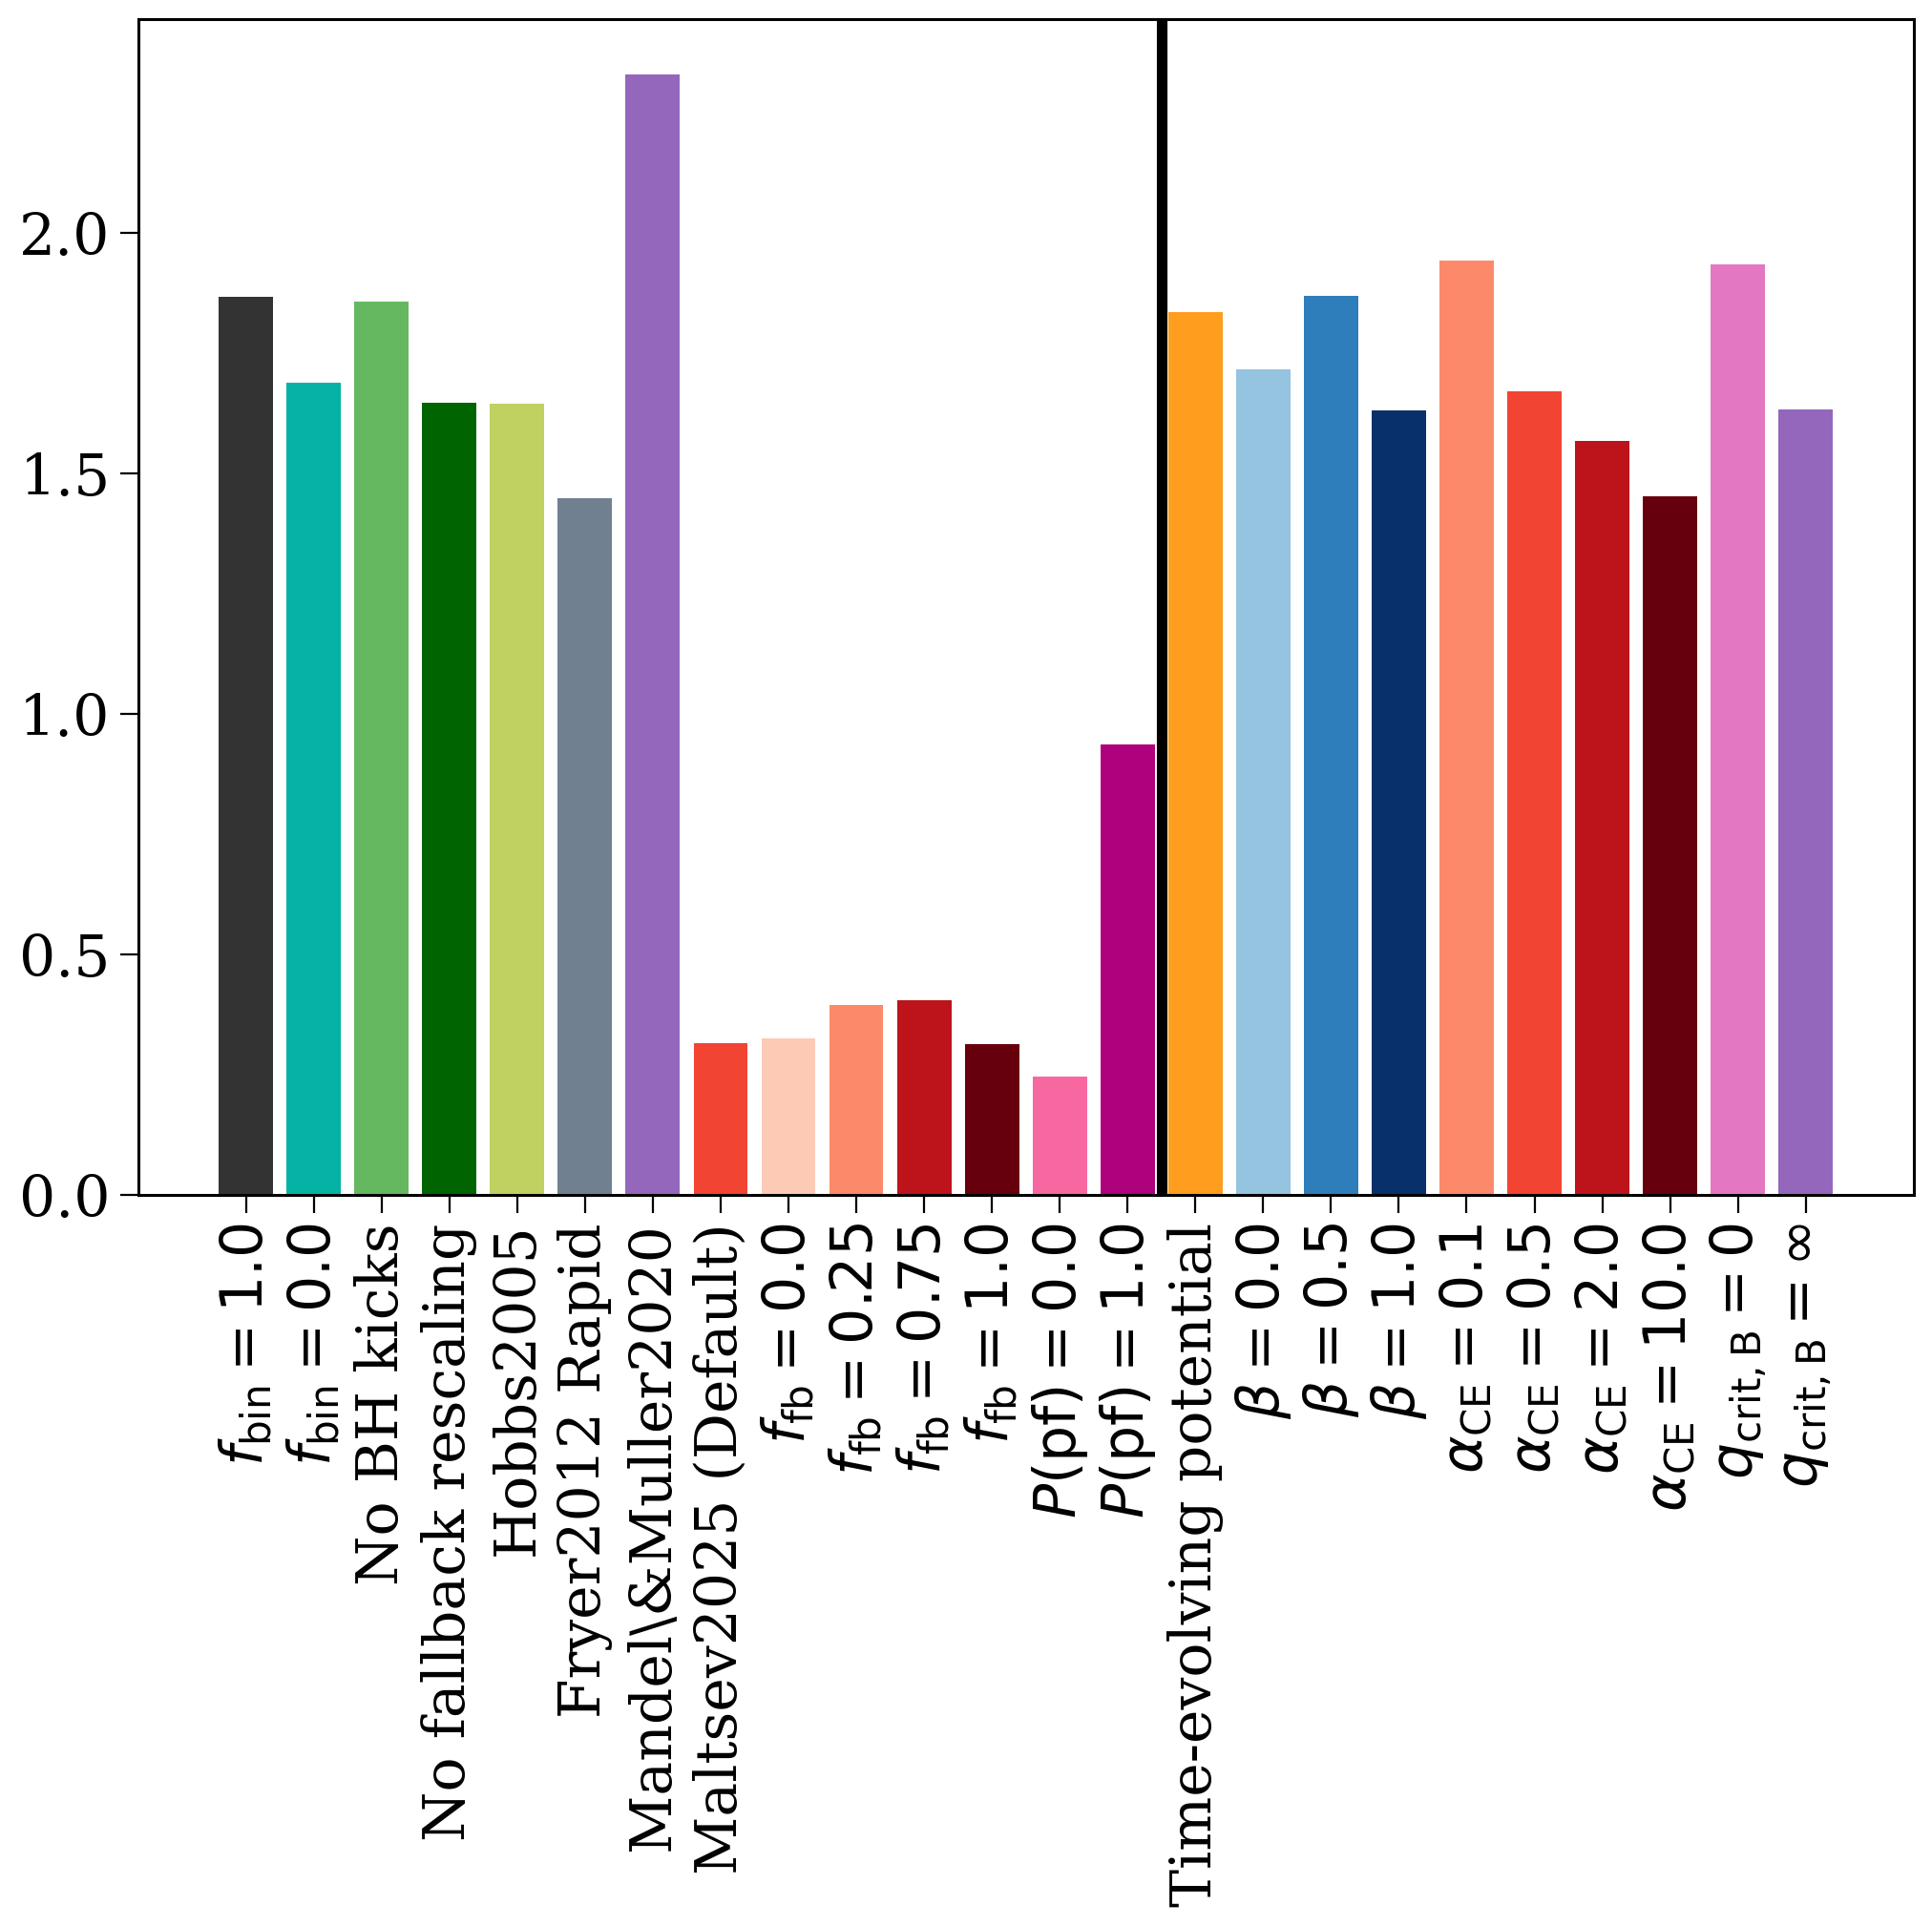

In [12]:
reload(constants)
import matplotlib.pyplot as plt

# make a bar plot of the number of BHs in each model
plt.bar(df.index, df["$N_{\\rm BH} / 10^8$"], color=constants.SIMULATION_COLOURS)

plt.axvline(13.5, color="black", lw=4)

# rotate x labels
plt.xticks(rotation=90);

/tmp/ipykernel_1643103/1096203266.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(yticklabels, rotation=45, fontsize=12)


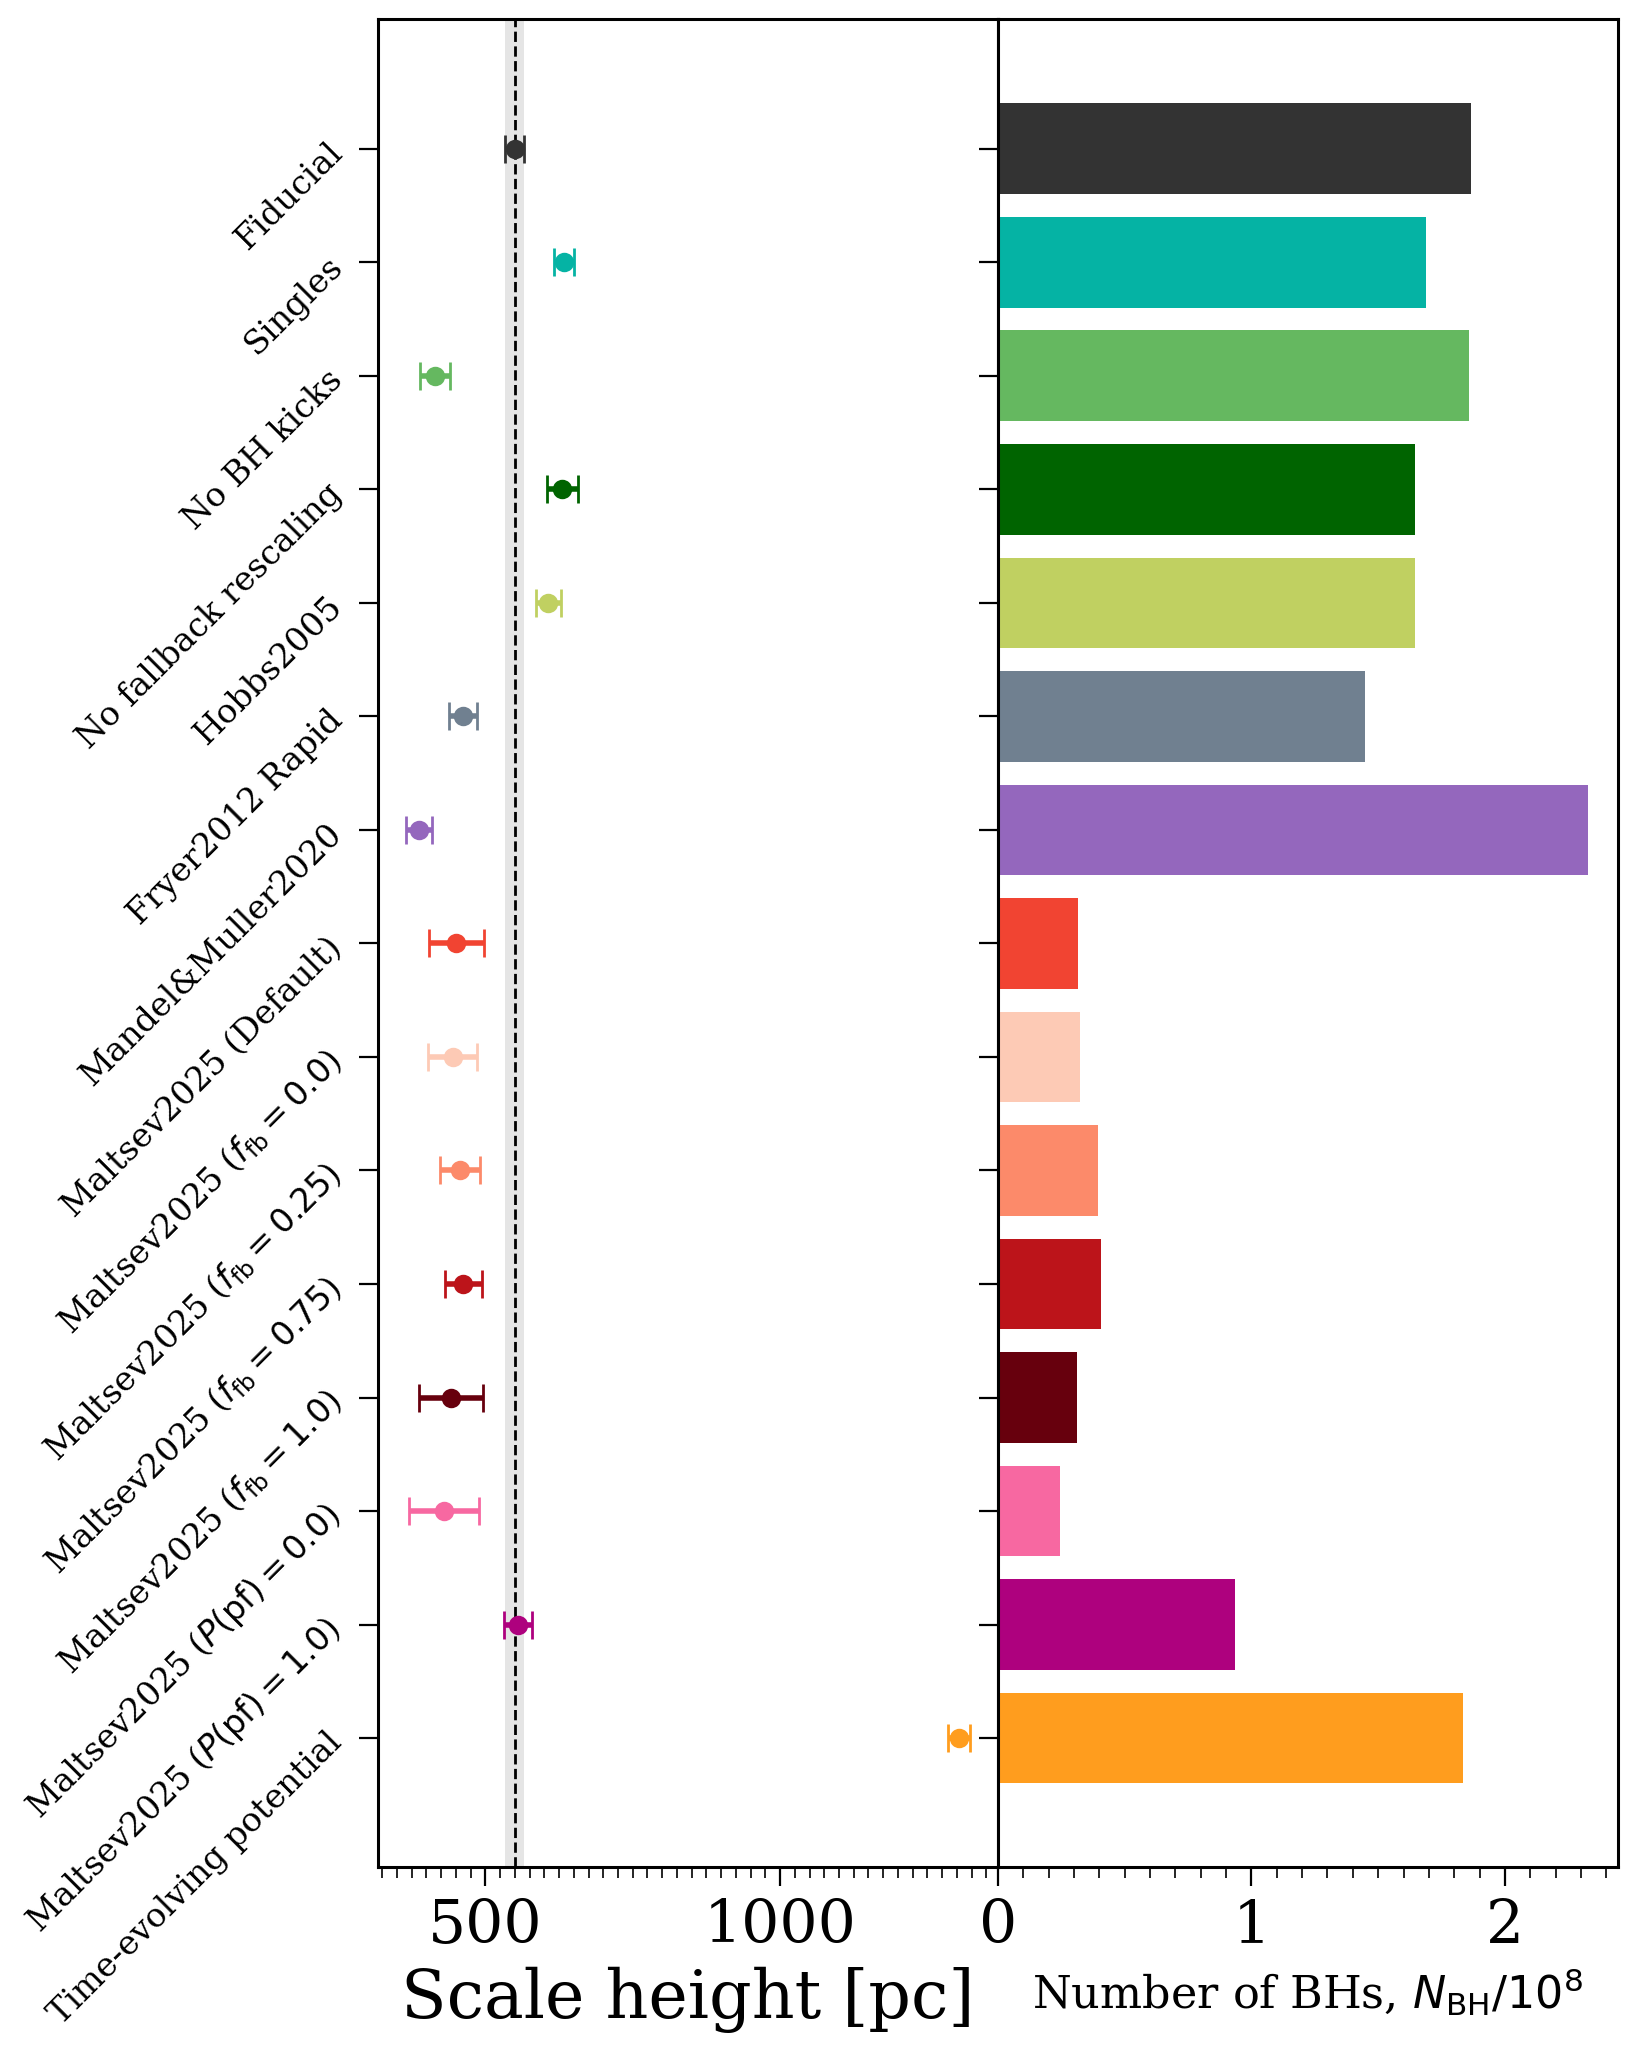

In [13]:
reload(constants)

fig, axes = plt.subplots(1, 2, figsize=(8, 12), sharey=True)

fig.subplots_adjust(wspace=0.0)

yticklabels = []

# make a scatter plot of the scale heights
ii = 0
for i, row in df.iterrows():
    if i == r"$\beta = 0.0$":
        break
    axes[0].errorbar(x=row["$h_z$ (pc)"], xerr=row["$\\sigma_{h_z}$ (pc)"], y=plot_labels[ii], color=constants.SIMULATION_COLOURS[ii], marker='o', capsize=5, lw=2)
    yticklabels.append(plot_labels[ii])
    ii += 1

axes[0].set(
    xlabel="Scale height [pc]"
)

axes[0].axvline(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"], color="black", lw=1, ls="--")
axes[0].axvspan(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] - df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] + df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], color="black", alpha=0.1, lw=0)

axes[0].set_yticklabels(yticklabels, rotation=45, fontsize=12)
axes[0].invert_yaxis()

axes[0].xaxis.set_minor_locator(plt.MultipleLocator(25))

plot_df = df.loc[main_labels]
axes[1].barh([plot_labels[i] for i in range(len(main_labels))], plot_df["$N_{\\rm BH} / 10^8$"], color=[constants.SIMULATION_COLOURS[i] for i in range(len(main_labels))])

axes[1].set_xlabel(r"Number of BHs, $N_{\rm BH} / 10^8$", fontsize=16)

# axes[1].axvline(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"], color="black", lw=1, ls="--")
# axes[1].axvspan(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] - df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] + df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], color="black", label="No binaries", alpha=0.1, lw=0)

# axes[1].set_yticklabels([])

axes[1].xaxis.set_minor_locator(plt.MultipleLocator(.1))

# ax.axvline(1.2)

plt.show()

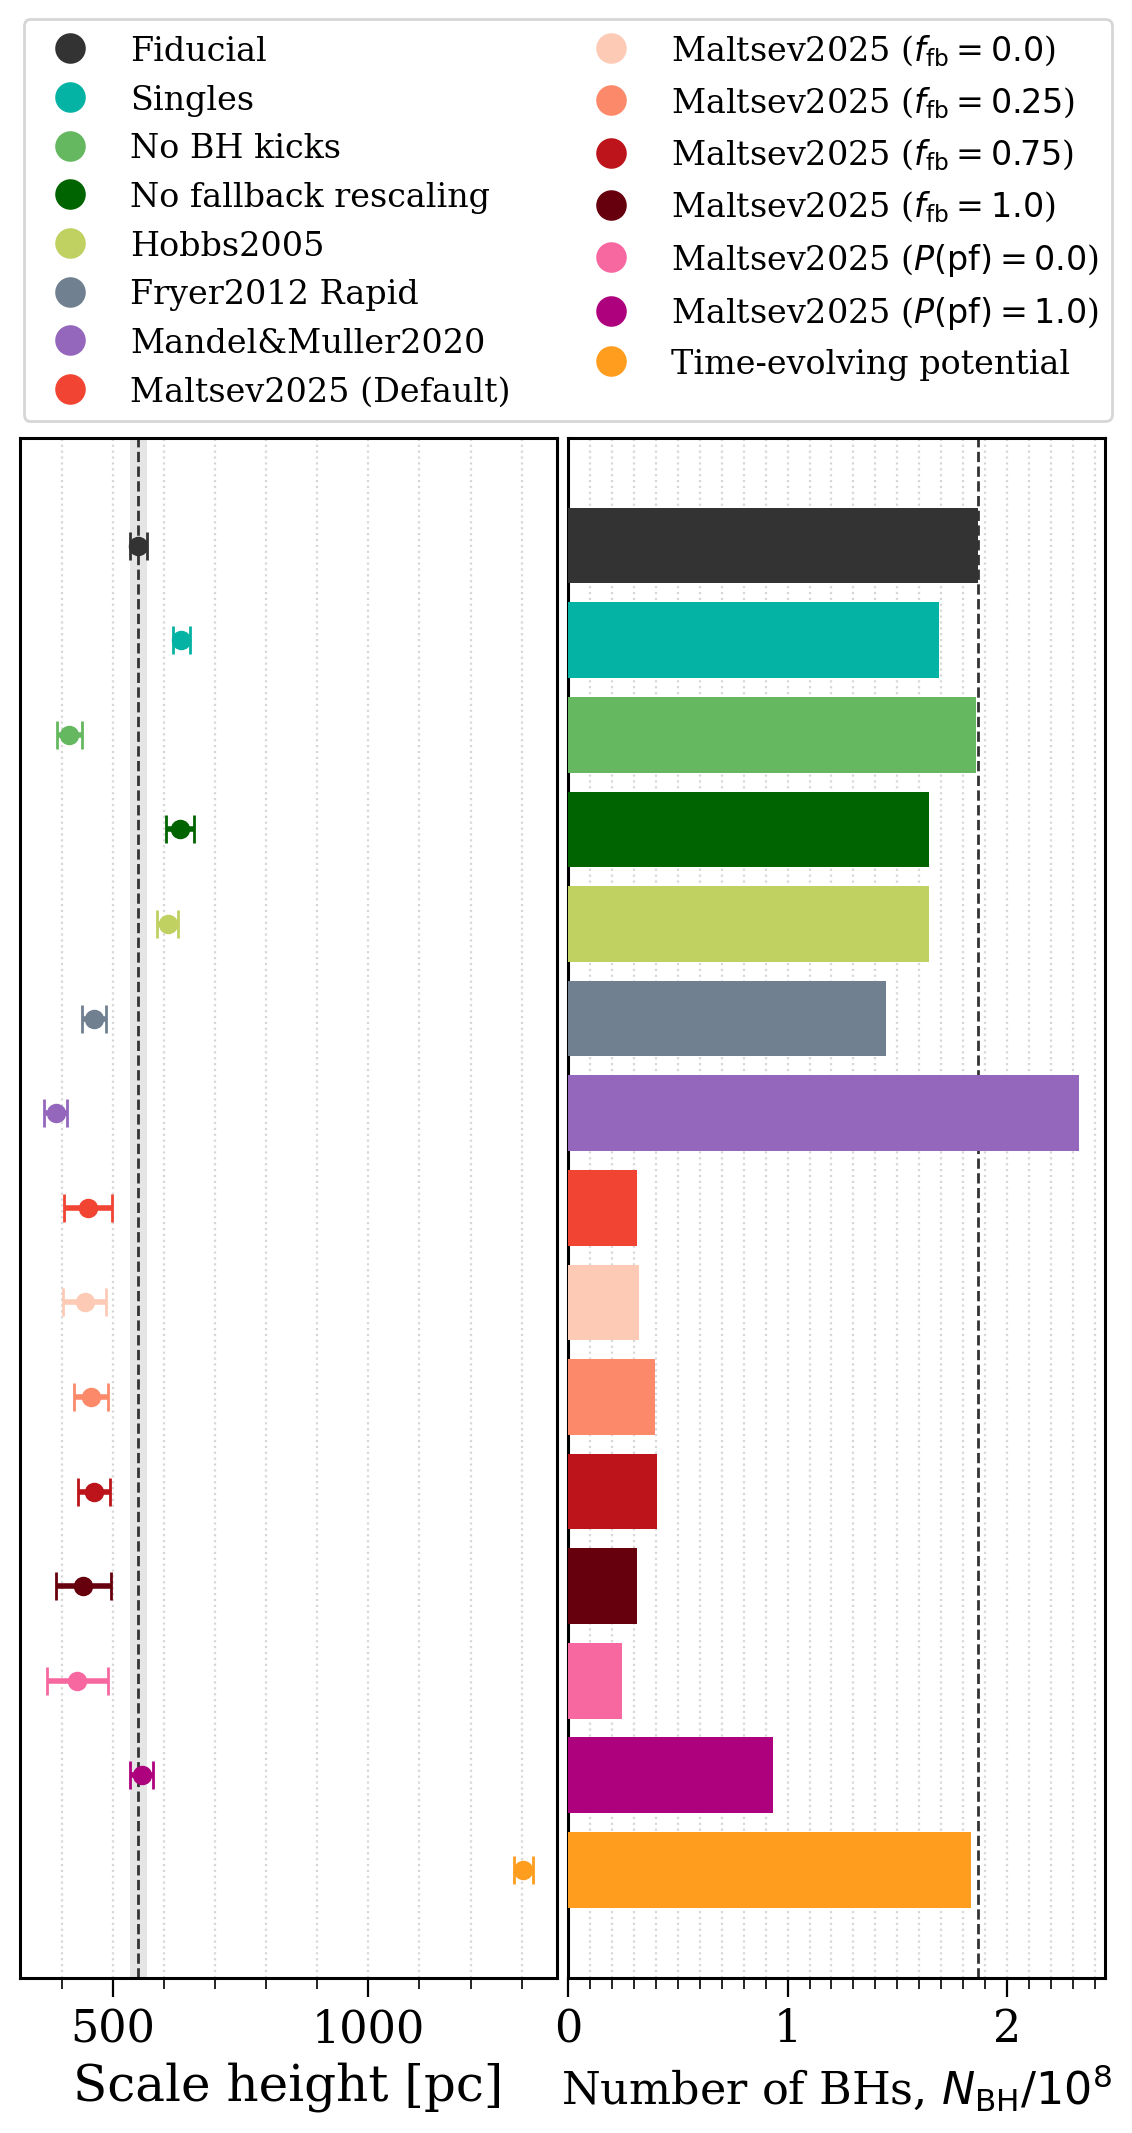

In [21]:
reload(constants)

fig, axes = plt.subplots(1, 2, figsize=(7, 10), sharey=True)

fig.subplots_adjust(wspace=0.02)

yticklabels = []

# make a scatter plot of the scale heights
ii = 0
for i, row in df.iterrows():
    if i == r"$\beta = 0.0$":
        break
    axes[0].errorbar(x=row["$h_z$ (pc)"], xerr=row["$\\sigma_{h_z}$ (pc)"], y=plot_labels[ii], color=constants.SIMULATION_COLOURS[ii], marker='o', capsize=5, lw=2)
    yticklabels.append(plot_labels[ii])
    ii += 1

# create a legend with the labels
handles = [plt.Line2D([0], [0], color=constants.SIMULATION_COLOURS[i], marker='o', linestyle='', markersize=10) for i in range(len(main_labels))]
axes[1].legend(handles, yticklabels, loc="lower center", fontsize=12, ncol=2, bbox_to_anchor=(0.0, 1.0))

axes[0].set(
    yticks=[]
)
axes[0].set_xlabel("Scale height [pc]", fontsize=18)

axes[0].axvline(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"], color="#333", lw=1, ls="--")
axes[0].axvspan(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] - df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] + df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], color="black", alpha=0.1, lw=0)
axes[0].invert_yaxis()
# axes[0].xaxis.set_major_locator(plt.MultipleLocator(100))
axes[0].xaxis.set_minor_locator(plt.MultipleLocator(100))


plot_df = df.loc[main_labels]
axes[1].barh([plot_labels[i] for i in range(len(main_labels))], plot_df["$N_{\\rm BH} / 10^8$"], color=[constants.SIMULATION_COLOURS[i] for i in range(len(main_labels))], zorder=10)
axes[1].set_xlabel(r"Number of BHs, $N_{\rm BH} / 10^8$", fontsize=16)
axes[1].xaxis.set_major_locator(plt.MultipleLocator(1))
axes[1].xaxis.set_minor_locator(plt.MultipleLocator(.1))
axes[1].axvline(plot_df["$N_{\\rm BH} / 10^8$"].values[0], color="#333", ls="--", zorder=-1, lw=1)

axes[0].grid(True, which='both', axis='x', ls=':', alpha=0.5, zorder=-100)
axes[1].grid(True, which='both', axis='x', ls=':', alpha=0.5, zorder=-100)

for ax in axes:
    ax.tick_params(which='both', axis='x', labelsize=16)

# plt.savefig("../plots/bh_summary_stats.pdf", format='pdf', bbox_inches='tight')

plt.show()

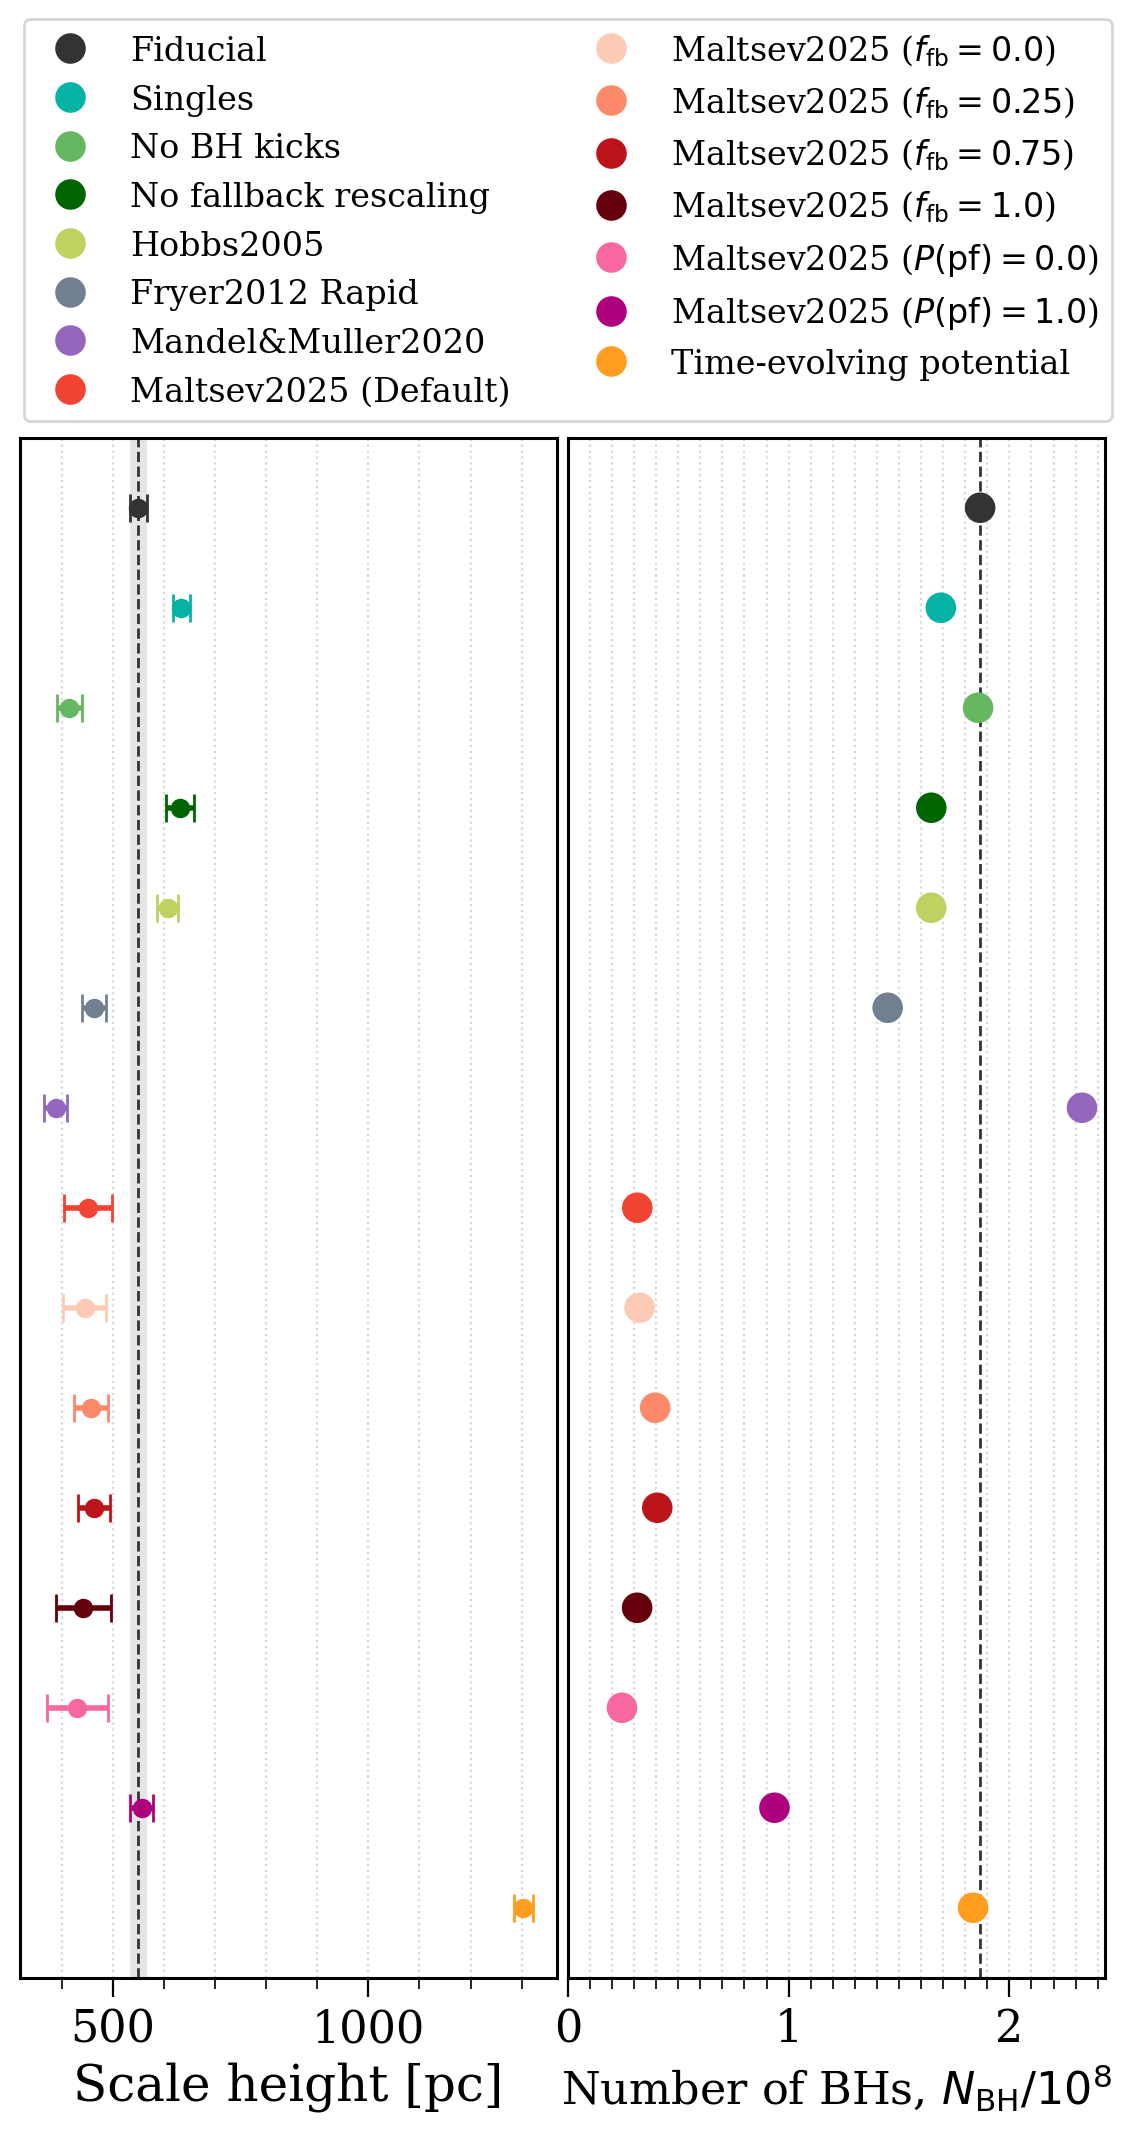

In [23]:
reload(constants)

fig, axes = plt.subplots(1, 2, figsize=(7, 10), sharey=True)

fig.subplots_adjust(wspace=0.02)

yticklabels = []

# make a scatter plot of the scale heights
ii = 0
for i, row in df.iterrows():
    if i == r"$\beta = 0.0$":
        break
    axes[0].errorbar(x=row["$h_z$ (pc)"], xerr=row["$\\sigma_{h_z}$ (pc)"], y=plot_labels[ii], color=constants.SIMULATION_COLOURS[ii], marker='o', markersize=6, capsize=5, lw=2)
    yticklabels.append(plot_labels[ii])
    ii += 1

# create a legend with the labels
handles = [plt.Line2D([0], [0], color=constants.SIMULATION_COLOURS[i], marker='o', linestyle='', markersize=10) for i in range(len(main_labels))]
axes[1].legend(handles, yticklabels, loc="lower center", fontsize=12, ncol=2, bbox_to_anchor=(0.0, 1.0))

axes[0].set(
    yticks=[]
)
axes[0].set_xlabel("Scale height [pc]", fontsize=18)

axes[0].axvline(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"], color="#333", lw=1, ls="--")
axes[0].axvspan(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] - df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] + df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], color="black", alpha=0.1, lw=0)
axes[0].invert_yaxis()
# axes[0].xaxis.set_major_locator(plt.MultipleLocator(100))
axes[0].xaxis.set_minor_locator(plt.MultipleLocator(100))


plot_df = df.loc[main_labels]
axes[1].scatter(plot_df["$N_{\\rm BH} / 10^8$"], [plot_labels[i] for i in range(len(main_labels))],
                color=[constants.SIMULATION_COLOURS[i] for i in range(len(main_labels))], zorder=10,
                s=100)
axes[1].set_xlabel(r"Number of BHs, $N_{\rm BH} / 10^8$", fontsize=16)
axes[1].set_xlim(left=0)
axes[1].xaxis.set_major_locator(plt.MultipleLocator(1))
axes[1].xaxis.set_minor_locator(plt.MultipleLocator(.1))
axes[1].axvline(plot_df["$N_{\\rm BH} / 10^8$"].values[0], color="#333", ls="--", zorder=-1, lw=1)


axes[0].grid(True, which='both', axis='x', ls=':', alpha=0.5, zorder=-100)
axes[1].grid(True, which='both', axis='x', ls=':', alpha=0.5, zorder=-100)

for ax in axes:
    ax.tick_params(which='both', axis='x', labelsize=16)

plt.savefig("../plots/bh_summary_stats.pdf", format='pdf', bbox_inches='tight')

plt.show()

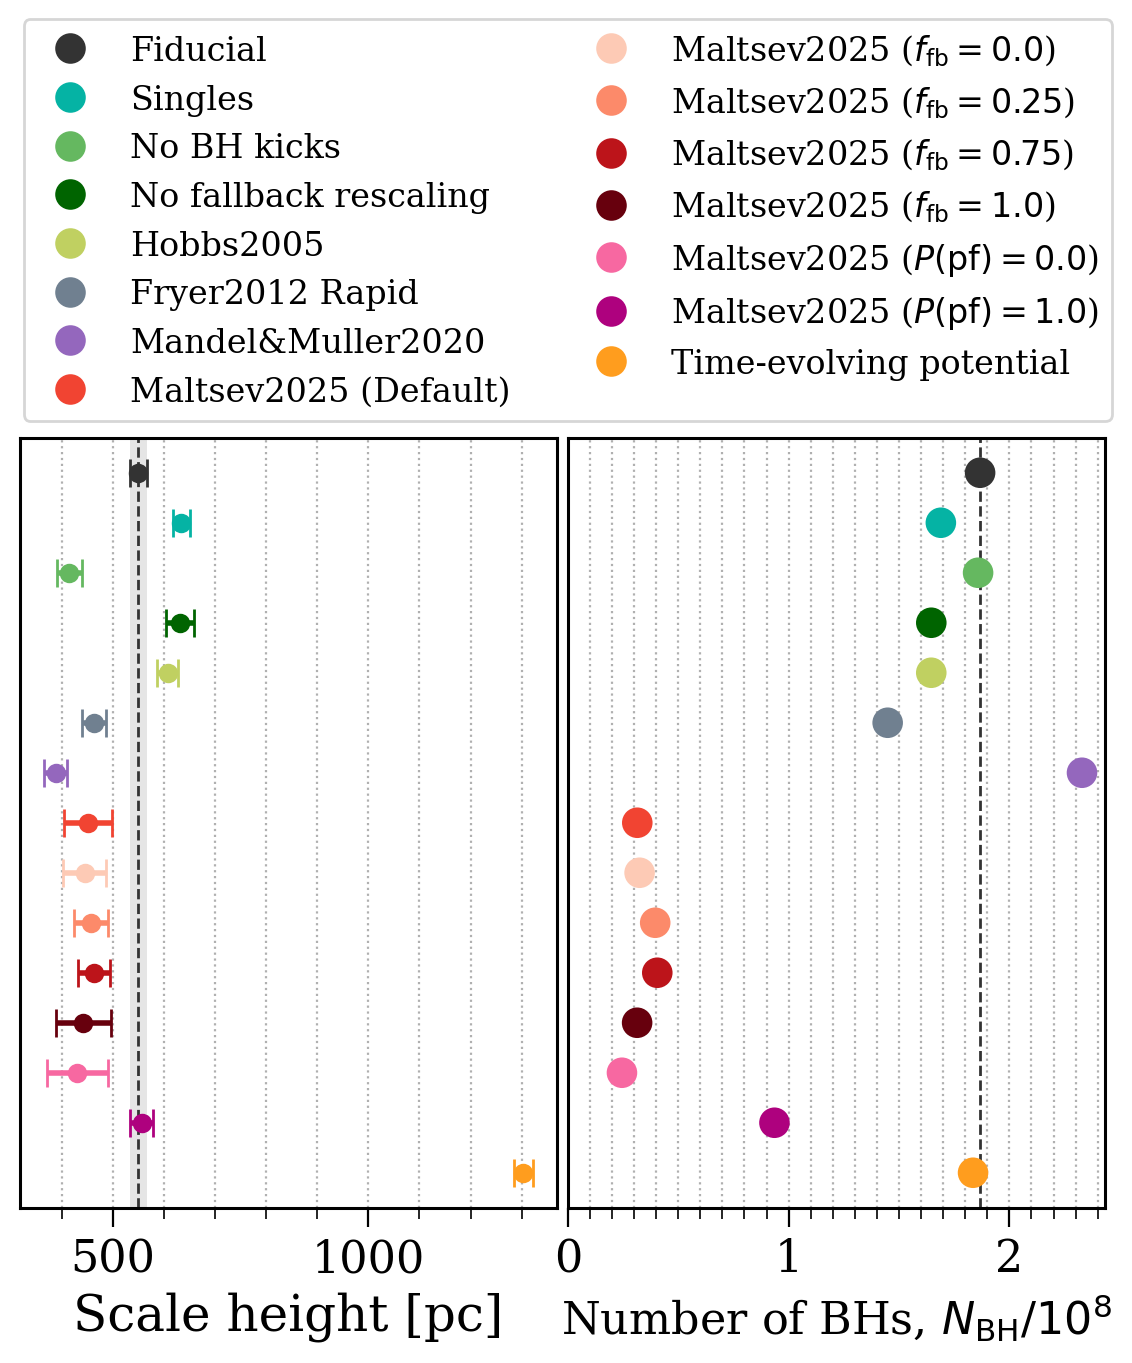

In [27]:
reload(constants)

fig, axes = plt.subplots(1, 2, figsize=(7, 5), sharey=True)

fig.subplots_adjust(wspace=0.02)

yticklabels = []

# make a scatter plot of the scale heights
ii = 0
for i, row in df.iterrows():
    if i == r"$\beta = 0.0$":
        break
    axes[0].errorbar(x=row["$h_z$ (pc)"], xerr=row["$\\sigma_{h_z}$ (pc)"], y=plot_labels[ii], color=constants.SIMULATION_COLOURS[ii], marker='o', markersize=6, capsize=5, lw=2)
    yticklabels.append(plot_labels[ii])
    ii += 1

# create a legend with the labels
handles = [plt.Line2D([0], [0], color=constants.SIMULATION_COLOURS[i], marker='o', linestyle='', markersize=10) for i in range(len(main_labels))]
axes[1].legend(handles, yticklabels, loc="lower center", fontsize=12, ncol=2, bbox_to_anchor=(0.0, 1.0))

axes[0].set(
    yticks=[]
)
axes[0].set_xlabel("Scale height [pc]", fontsize=18)

axes[0].axvline(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"], color="#333", lw=1, ls="--")
axes[0].axvspan(df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] - df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], df.loc[r"$f_{\rm bin} = 1.0$", "$h_z$ (pc)"] + df.loc[r"$f_{\rm bin} = 1.0$", "$\\sigma_{h_z}$ (pc)"], color="black", alpha=0.1, lw=0)
axes[0].invert_yaxis()
# axes[0].xaxis.set_major_locator(plt.MultipleLocator(100))
axes[0].xaxis.set_minor_locator(plt.MultipleLocator(100))


plot_df = df.loc[main_labels]
axes[1].scatter(plot_df["$N_{\\rm BH} / 10^8$"], [plot_labels[i] for i in range(len(main_labels))],
                color=[constants.SIMULATION_COLOURS[i] for i in range(len(main_labels))], zorder=10,
                s=100)
axes[1].set_xlabel(r"Number of BHs, $N_{\rm BH} / 10^8$", fontsize=16)
axes[1].set_xlim(left=0)
axes[1].xaxis.set_major_locator(plt.MultipleLocator(1))
axes[1].xaxis.set_minor_locator(plt.MultipleLocator(.1))
axes[1].axvline(plot_df["$N_{\\rm BH} / 10^8$"].values[0], color="#333", ls="--", zorder=-1, lw=1)


axes[0].grid(True, which='both', axis='x', ls=':', zorder=-100)
axes[1].grid(True, which='both', axis='x', ls=':', zorder=-100)

for ax in axes:
    ax.tick_params(which='both', axis='x', labelsize=16)

plt.savefig("../plots/bh_summary_stats.pdf", format='pdf', bbox_inches='tight')

plt.show()